# Beauty Sequential Recommendation Benchmark - Full 5 Models + BSARec Tuning

Notebook này giữ nguyên hướng chạy **5 mô hình** trong đề tài:

1. **Popularity**
2. **GRU4Rec**
3. **SASRec**
4. **BERT4Rec**
5. **BSARec**

Các điểm đã chỉnh theo yêu cầu:

- Dữ liệu mặc định: `/kaggle/input/datasets/namtrngge/dataset/Beauty.txt`.
- Vẫn chạy đủ 5 model ở bước benchmark cuối.
- Thêm tuning siêu tham số riêng cho **BSARec** gồm `alpha` và `c`.
- Chọn `alpha` và `c` tốt nhất theo **validation NDCG@10**, không chọn trực tiếp bằng test set.
- **Popularity vẫn được tính HR@K, NDCG@K và MRR** bằng cùng hàm full-ranking như các model khác.
- Code được tách cell rõ hơn và có comment tiếng Việt để dễ trình bày trong báo cáo/bảo vệ.


## 1. Import thư viện


In [10]:
import os
import glob
import json
import math
import time
import copy
import shutil
import random
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader, RandomSampler
from IPython.display import display


## 2. Cấu hình chung


In [11]:
def set_seed(seed: int = 42):
    """Cố định seed để kết quả huấn luyện có khả năng lặp lại tốt hơn."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True


@dataclass
class CFG:
    # Đường dẫn dữ liệu trên Kaggle.
    data_path: str = "/kaggle/input/datasets/namtrngge/dataset/Beauty.txt"
    maps_path: Optional[str] = "/kaggle/input/datasets/namtrngge/dataset/AmazonBeauty_maps.json"
    output_dir: str = "/kaggle/working/seqrec_outputs"

models_to_run: Tuple[str, ...] = ("Popularity", "GRU4Rec", "SASRec", "BERT4Rec", "BSARec")

    # Tham số chung.
    seed: int = 42
    max_seq_length: int = 50
    hidden_size: int = 64
    num_hidden_layers: int = 2
    num_attention_heads: int = 2
    hidden_act: str = "gelu"
    hidden_dropout_prob: float = 0.5
    attention_probs_dropout_prob: float = 0.5
    initializer_range: float = 0.02

    # Tham số train.
    batch_size: int = 256
    eval_batch_size: int = 512
    epochs: int = 200
    patience: int = 10
    lr: float = 1e-3
    weight_decay: float = 0.0
    adam_beta1: float = 0.9
    adam_beta2: float = 0.999
    num_workers: int = 2

    # Cấu hình mặc định của BSARec.
    # alpha: hệ số trộn nhánh frequency và self-attention.
    # c: ngưỡng tần số cắt trong FrequencyLayer.
    bsarec_c: int = 3
    bsarec_alpha: float = 0.9

    # Cấu hình tuning riêng cho BSARec.
    # Chọn theo validation set, không chọn bằng test set.
    run_bsarec_tuning: bool = True
    bsarec_alpha_grid: Tuple[float, ...] = (0.5, 0.7, 0.9)
    bsarec_c_grid: Tuple[int, ...] = (1, 3, 5, 10)
    tuning_metric: str = "NDCG@10"
    tuning_epochs: int = 60
    tuning_patience: int = 5

    # BERT4Rec.
    bert_mask_ratio: float = 0.2

    # Dùng để test nhanh notebook. Để None khi chạy thật trên Kaggle.
    max_users_debug: Optional[int] = None


cfg = CFG()
set_seed(cfg.seed)
os.makedirs(cfg.output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Output dir:", cfg.output_dir)


Device: cuda
Output dir: /kaggle/working/seqrec_outputs


## 3. Đọc dữ liệu


In [12]:
def resolve_data_path(path: str) -> str:
    """Tìm file dữ liệu trong các vị trí thường gặp trên Kaggle."""
    candidates = [
        path,
        path.replace("beauty.txt", "Beauty.txt"),
        "/kaggle/input/dataset/beauty.txt",
        "/kaggle/input/dataset/Beauty.txt",
        "/kaggle/input/datasets/namtrngge/dataset/Beauty.txt",
    ]

    for candidate in candidates:
        if os.path.exists(candidate):
            return candidate

    matches = glob.glob("/kaggle/input/**/*.txt", recursive=True)
    beauty_matches = [p for p in matches if os.path.basename(p).lower() == "beauty.txt"]

    if beauty_matches:
        return beauty_matches[0]

    if matches:
        print("Không thấy đúng file cấu hình. Một số file .txt tìm được:")
        for p in matches[:20]:
            print(" ", p)

    raise FileNotFoundError(f"Dataset not found: {path}")


def load_user_sequences(path: str, max_users: Optional[int] = None) -> Tuple[List[List[int]], int, Dict]:
    """Đọc dữ liệu theo 2 định dạng phổ biến.

    Hỗ trợ:
    - Sequence format: user_id item_id item_id item_id ...
    - Pair format:     user_id item_id

    Nếu là pair format, hàm sẽ gom các item theo user theo thứ tự trong file.
    """
    raw_rows = []
    first_lines = []
    bad_lines = 0

    with open(path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue

            if len(first_lines) < 5:
                first_lines.append(line)

            parts = line.split()
            try:
                values = [int(x) for x in parts]
            except ValueError:
                bad_lines += 1
                continue

            if len(values) >= 2:
                raw_rows.append(values)

    if not raw_rows:
        raise ValueError(
            "Không đọc được dòng numeric nào trong dataset. "
            f"First non-empty lines: {first_lines}"
        )

    token_lengths = [len(row) for row in raw_rows]
    token_length_counts = dict(pd.Series(token_lengths).value_counts().sort_index())
    pair_ratio = sum(1 for n in token_lengths if n == 2) / len(token_lengths)
    format_detected = "pair" if pair_ratio >= 0.95 else "sequence"

    sequences = []
    max_item = 0

    if format_detected == "pair":
        user_to_items = {}
        user_order = []

        for user_id, item_id in raw_rows:
            if user_id not in user_to_items:
                user_to_items[user_id] = []
                user_order.append(user_id)

            user_to_items[user_id].append(item_id)
            max_item = max(max_item, item_id)

        for user_id in user_order:
            items = user_to_items[user_id]
            if len(items) >= 3:
                sequences.append(items)
                if max_users is not None and len(sequences) >= max_users:
                    break
    else:
        for row in raw_rows:
            items = row[1:]
            if len(items) >= 3:
                max_item = max(max_item, max(items))
                sequences.append(items)

                if max_users is not None and len(sequences) >= max_users:
                    break

    info = {
        "format_detected": format_detected,
        "raw_nonempty_numeric_rows": len(raw_rows),
        "bad_lines": bad_lines,
        "token_length_counts": token_length_counts,
        "first_lines": first_lines,
    }

    if not sequences:
        raise ValueError(
            "Không tạo được user sequence hợp lệ. Mỗi user cần ít nhất 3 item "
            "để chia train/valid/test."
        )

    return sequences, max_item, info


In [13]:
# Đọc dataset và in thống kê cơ bản.
data_path = resolve_data_path(cfg.data_path)
sequences, num_items, load_info = load_user_sequences(data_path, cfg.max_users_debug)

lengths = np.array([len(seq) for seq in sequences], dtype=np.int64)

print("Data path:", data_path)
print("Detected format:", load_info["format_detected"])
print("Token length counts:", load_info["token_length_counts"])
print("First lines:", load_info["first_lines"])
print(f"Users: {len(sequences):,}")
print(f"Items: {num_items:,}")
print(f"Interactions: {int(lengths.sum()):,}")
print(f"Seq len: min={lengths.min()}, avg={lengths.mean():.2f}, max={lengths.max()}")
print("First 3 sequences:", sequences[:3])


Data path: /kaggle/input/datasets/namtrngge/dataset/Beauty.txt
Detected format: sequence
Token length counts: {6: np.int64(7162), 7: np.int64(4221), 8: np.int64(2680), 9: np.int64(1811), 10: np.int64(1366), 11: np.int64(881), 12: np.int64(695), 13: np.int64(558), 14: np.int64(439), 15: np.int64(361), 16: np.int64(262), 17: np.int64(207), 18: np.int64(213), 19: np.int64(141), 20: np.int64(118), 21: np.int64(112), 22: np.int64(117), 23: np.int64(84), 24: np.int64(66), 25: np.int64(73), 26: np.int64(74), 27: np.int64(61), 28: np.int64(54), 29: np.int64(44), 30: np.int64(44), 31: np.int64(38), 32: np.int64(30), 33: np.int64(38), 34: np.int64(20), 35: np.int64(19), 36: np.int64(21), 37: np.int64(19), 38: np.int64(23), 39: np.int64(24), 40: np.int64(22), 41: np.int64(15), 42: np.int64(17), 43: np.int64(7), 44: np.int64(10), 45: np.int64(10), 46: np.int64(15), 47: np.int64(7), 48: np.int64(11), 49: np.int64(8), 50: np.int64(4), 51: np.int64(8), 52: np.int64(9), 53: np.int64(8), 54: np.int64(9

In [15]:
def resolve_optional_maps_path(path: Optional[str]) -> Optional[str]:
    """Tìm file mapping giữa item id nội bộ và item id gốc nếu có."""
    candidates = []

    if path:
        candidates.append(path)

    candidates.extend([
        "/kaggle/input/datasets/namtrngge/dataset/AmazonBeauty_maps.json",
        "/kaggle/input/datasets/namtrngge/dataset/AmazonBeauty2018_maps.json",
        "/kaggle/input/dataset/AmazonBeauty_maps.json",
        "/kaggle/input/dataset/AmazonBeauty2018_maps.json",
    ])

    for candidate in candidates:
        if candidate and os.path.exists(candidate):
            return candidate

    matches = glob.glob("/kaggle/input/**/*maps*.json", recursive=True)
    return matches[0] if matches else None


maps_path = resolve_optional_maps_path(cfg.maps_path)
id2item = None
item2id = None

if maps_path:
    with open(maps_path, "r", encoding="utf-8") as f:
        maps_payload = json.load(f)

    id2item = maps_payload.get("id2item")
    item2id = maps_payload.get("item2id")

    print("Maps path:", maps_path)
    print("id2item loaded:", isinstance(id2item, dict))
    print("item2id loaded:", isinstance(item2id, dict))
else:
    maps_payload = {}
    print("Không thấy file maps JSON. Model vẫn chạy bằng numeric item id.")


Không thấy file maps JSON. Model vẫn chạy bằng numeric item id.


## 4. Tạo train/validation/test


In [16]:
def pad_left(items: List[int], max_len: int) -> List[int]:
    """Lấy các item gần nhất và padding 0 bên trái cho đủ max_len."""
    items = items[-max_len:]
    return [0] * (max_len - len(items)) + items


def neg_sample(item_set: set, num_items: int) -> int:
    """Sinh một item âm không nằm trong tập item đã tương tác."""
    item = random.randint(1, num_items)
    while item in item_set:
        item = random.randint(1, num_items)
    return item


class TrainSeqDataset(Dataset):
    """Dataset train cho next-item recommendation.

    Với mỗi user:
    - item cuối cùng dùng cho test.
    - item áp cuối dùng cho validation.
    - các prefix trước đó dùng để tạo mẫu huấn luyện.
    """

    def __init__(self, sequences: List[List[int]], num_items: int, max_len: int):
        self.examples = []
        self.user_ids = []
        self.num_items = num_items
        self.max_len = max_len

        for user_idx, seq in enumerate(sequences):
            train_seq = seq[-(max_len + 2):-2]

            for i in range(len(train_seq)):
                self.examples.append(train_seq[: i + 1])
                self.user_ids.append(user_idx)

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, index: int):
        items = self.examples[index]
        answer = items[-1]
        input_items = items[:-1]
        input_ids = pad_left(input_items, self.max_len)
        neg_answer = neg_sample(set(items), self.num_items)

        return (
            torch.tensor(self.user_ids[index], dtype=torch.long),
            torch.tensor(input_ids, dtype=torch.long),
            torch.tensor(answer, dtype=torch.long),
            torch.tensor(neg_answer, dtype=torch.long),
        )


def make_eval_arrays(sequences: List[List[int]], max_len: int, mode: str):
    """Tạo dữ liệu validation hoặc test theo leave-one-out."""
    input_ids, answers, histories, user_ids = [], [], [], []

    for user_idx, seq in enumerate(sequences):
        if mode == "valid":
            history = seq[:-2]
            answer = seq[-2]
        elif mode == "test":
            history = seq[:-1]
            answer = seq[-1]
        else:
            raise ValueError(mode)

        input_ids.append(pad_left(history, max_len))
        answers.append(answer)
        histories.append(history)
        user_ids.append(user_idx)

    return (
        torch.tensor(input_ids, dtype=torch.long),
        torch.tensor(answers, dtype=torch.long),
        histories,
        torch.tensor(user_ids, dtype=torch.long),
    )


In [17]:
train_dataset = TrainSeqDataset(sequences, num_items, cfg.max_seq_length)

valid_inputs, valid_answers, valid_histories, valid_user_ids = make_eval_arrays(
    sequences, cfg.max_seq_length, "valid"
)

test_inputs, test_answers, test_histories, test_user_ids = make_eval_arrays(
    sequences, cfg.max_seq_length, "test"
)

print(f"Train examples: {len(train_dataset):,}")
print(f"Valid users: {len(valid_answers):,}")
print(f"Test users: {len(test_answers):,}")


Train examples: 150,258
Valid users: 22,363
Test users: 22,363


## 5. Các lớp Transformer dùng chung


In [18]:
class LayerNorm(nn.Module):
    """LayerNorm tự viết để giữ cấu trúc gần với code gốc."""

    def __init__(self, hidden_size, eps=1e-12):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(hidden_size))
        self.bias = nn.Parameter(torch.zeros(hidden_size))
        self.variance_epsilon = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        variance = (x - mean).pow(2).mean(-1, keepdim=True)
        x = (x - mean) / torch.sqrt(variance + self.variance_epsilon)
        return self.weight * x + self.bias


class FeedForward(nn.Module):
    """Mạng FFN theo từng vị trí trong Transformer."""

    def __init__(self, args):
        super().__init__()
        hidden_size = args.hidden_size
        inner_size = 4 * args.hidden_size

        self.dense_1 = nn.Linear(hidden_size, inner_size)
        self.dense_2 = nn.Linear(inner_size, hidden_size)
        self.LayerNorm = LayerNorm(hidden_size, eps=1e-12)
        self.dropout = nn.Dropout(args.hidden_dropout_prob)
        self.hidden_act = args.hidden_act

    def gelu(self, x):
        return x * 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))

    def forward(self, input_tensor):
        hidden_states = self.dense_1(input_tensor)

        if self.hidden_act == "gelu":
            hidden_states = self.gelu(hidden_states)
        elif self.hidden_act == "relu":
            hidden_states = F.relu(hidden_states)
        else:
            hidden_states = torch.tanh(hidden_states)

        hidden_states = self.dense_2(hidden_states)
        hidden_states = self.dropout(hidden_states)
        hidden_states = self.LayerNorm(hidden_states + input_tensor)
        return hidden_states


In [19]:
class MultiHeadAttention(nn.Module):
    """Self-attention nhiều head.

    Input được chiếu thành Query, Key, Value.
    Attention mask dùng để chặn padding hoặc chặn tương lai trong SASRec/BSARec.
    """

    def __init__(self, args):
        super().__init__()

        if args.hidden_size % args.num_attention_heads != 0:
            raise ValueError("hidden_size must be divisible by num_attention_heads")

        self.num_attention_heads = args.num_attention_heads
        self.attention_head_size = args.hidden_size // args.num_attention_heads
        self.all_head_size = self.num_attention_heads * self.attention_head_size
        self.sqrt_attention_head_size = math.sqrt(self.attention_head_size)

        self.query = nn.Linear(args.hidden_size, self.all_head_size)
        self.key = nn.Linear(args.hidden_size, self.all_head_size)
        self.value = nn.Linear(args.hidden_size, self.all_head_size)

        self.softmax = nn.Softmax(dim=-1)
        self.attn_dropout = nn.Dropout(args.attention_probs_dropout_prob)

        self.dense = nn.Linear(args.hidden_size, args.hidden_size)
        self.LayerNorm = nn.LayerNorm(args.hidden_size, eps=1e-12)
        self.out_dropout = nn.Dropout(args.hidden_dropout_prob)

    def transpose_for_scores(self, x):
        new_shape = x.size()[:-1] + (self.num_attention_heads, self.attention_head_size)
        return x.view(*new_shape)

    def forward(self, input_tensor, attention_mask):
        mixed_query_layer = self.query(input_tensor)
        mixed_key_layer = self.key(input_tensor)
        mixed_value_layer = self.value(input_tensor)

        query_layer = self.transpose_for_scores(mixed_query_layer).permute(0, 2, 1, 3)
        key_layer = self.transpose_for_scores(mixed_key_layer).permute(0, 2, 3, 1)
        value_layer = self.transpose_for_scores(mixed_value_layer).permute(0, 2, 1, 3)

        attention_scores = torch.matmul(query_layer, key_layer) / self.sqrt_attention_head_size
        attention_scores = attention_scores + attention_mask

        attention_probs = self.softmax(attention_scores)
        attention_probs = self.attn_dropout(attention_probs)

        context_layer = torch.matmul(attention_probs, value_layer)
        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()
        context_layer = context_layer.view(*context_layer.size()[:-2], self.all_head_size)

        hidden_states = self.dense(context_layer)
        hidden_states = self.out_dropout(hidden_states)
        hidden_states = self.LayerNorm(hidden_states + input_tensor)

        return hidden_states


In [20]:
class TransformerBlock(nn.Module):
    """Một block Transformer gồm Self-Attention + FeedForward."""

    def __init__(self, args):
        super().__init__()
        self.layer = MultiHeadAttention(args)
        self.feed_forward = FeedForward(args)

    def forward(self, hidden_states, attention_mask):
        hidden_states = self.layer(hidden_states, attention_mask)
        hidden_states = self.feed_forward(hidden_states)
        return hidden_states


class TransformerEncoder(nn.Module):
    """Encoder xếp chồng nhiều TransformerBlock."""

    def __init__(self, args):
        super().__init__()
        block = TransformerBlock(args)
        self.blocks = nn.ModuleList([copy.deepcopy(block) for _ in range(args.num_hidden_layers)])

    def forward(self, hidden_states, attention_mask, output_all_encoded_layers=False):
        all_encoder_layers = [hidden_states]

        for layer_module in self.blocks:
            hidden_states = layer_module(hidden_states, attention_mask)

            if output_all_encoded_layers:
                all_encoder_layers.append(hidden_states)

        if not output_all_encoded_layers:
            all_encoder_layers.append(hidden_states)

        return all_encoder_layers


## 6. Lớp model cơ sở


In [21]:
@dataclass
class ModelArgs:
    """Tham số đưa vào từng model.

    Không lấy trực tiếp default từ cfg trong class này, vì sau khi tuning BSARec
    ta sẽ cập nhật cfg.bsarec_alpha và cfg.bsarec_c.
    """

    num_items: int
    max_seq_length: int
    hidden_size: int
    num_hidden_layers: int
    hidden_act: str
    num_attention_heads: int
    attention_probs_dropout_prob: float
    hidden_dropout_prob: float
    initializer_range: float
    batch_size: int
    gru_hidden_size: int
    c: int
    alpha: float
    mask_ratio: float

    @property
    def item_size(self):
        # item id chạy từ 0..num_items, trong đó 0 là padding.
        return self.num_items + 1


def make_model_args(
    num_items: int,
    bsarec_alpha: Optional[float] = None,
    bsarec_c: Optional[int] = None,
) -> ModelArgs:
    """Tạo ModelArgs từ cfg hiện tại, có thể override riêng alpha/c cho BSARec."""

    return ModelArgs(
        num_items=num_items,
        max_seq_length=cfg.max_seq_length,
        hidden_size=cfg.hidden_size,
        num_hidden_layers=cfg.num_hidden_layers,
        hidden_act=cfg.hidden_act,
        num_attention_heads=cfg.num_attention_heads,
        attention_probs_dropout_prob=cfg.attention_probs_dropout_prob,
        hidden_dropout_prob=cfg.hidden_dropout_prob,
        initializer_range=cfg.initializer_range,
        batch_size=cfg.batch_size,
        gru_hidden_size=cfg.hidden_size,
        c=cfg.bsarec_c if bsarec_c is None else int(bsarec_c),
        alpha=cfg.bsarec_alpha if bsarec_alpha is None else float(bsarec_alpha),
        mask_ratio=cfg.bert_mask_ratio,
    )


In [22]:
class SequentialRecModel(nn.Module):
    """Lớp cha cho các mô hình gợi ý tuần tự."""

    def __init__(self, args: ModelArgs):
        super().__init__()
        self.args = args
        self.num_items = args.num_items
        self.item_embeddings = nn.Embedding(args.item_size, args.hidden_size, padding_idx=0)
        self.position_embeddings = nn.Embedding(args.max_seq_length, args.hidden_size)
        self.batch_size = args.batch_size

    def add_position_embedding(self, sequence):
        seq_length = sequence.size(1)

        position_ids = torch.arange(seq_length, dtype=torch.long, device=sequence.device)
        position_ids = position_ids.unsqueeze(0).expand_as(sequence)

        item_embeddings = self.item_embeddings(sequence)
        position_embeddings = self.position_embeddings(position_ids)

        sequence_emb = item_embeddings + position_embeddings
        sequence_emb = self.LayerNorm(sequence_emb)
        sequence_emb = self.dropout(sequence_emb)

        return sequence_emb

    def init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            module.weight.data.normal_(mean=0.0, std=self.args.initializer_range)

        elif isinstance(module, LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)

        elif isinstance(module, nn.GRU):
            for name, param in module.named_parameters():
                if "weight" in name:
                    nn.init.xavier_uniform_(param)

        if isinstance(module, nn.Linear) and module.bias is not None:
            module.bias.data.zero_()

    def get_bi_attention_mask(self, item_seq):
        """Mask hai chiều: chỉ che padding, dùng cho BERT4Rec."""
        attention_mask = (item_seq > 0).long()
        extended_attention_mask = attention_mask.unsqueeze(1).unsqueeze(2)
        extended_attention_mask = extended_attention_mask.to(dtype=next(self.parameters()).dtype)
        return (1.0 - extended_attention_mask) * -10000.0

    def get_attention_mask(self, item_seq):
        """Causal mask: che padding và che item tương lai, dùng cho SASRec/BSARec."""
        attention_mask = (item_seq > 0).long()
        extended_attention_mask = attention_mask.unsqueeze(1).unsqueeze(2)

        max_len = attention_mask.size(-1)
        attn_shape = (1, max_len, max_len)

        subsequent_mask = torch.triu(torch.ones(attn_shape, device=item_seq.device), diagonal=1)
        subsequent_mask = (subsequent_mask == 0).unsqueeze(1).long()

        extended_attention_mask = extended_attention_mask * subsequent_mask
        extended_attention_mask = extended_attention_mask.to(dtype=next(self.parameters()).dtype)

        return (1.0 - extended_attention_mask) * -10000.0

    def predict(self, input_ids, user_ids=None, all_sequence_output=False):
        return self.forward(input_ids, user_ids, all_sequence_output)

    def full_sort_scores(self, input_ids, user_ids=None):
        """Tính điểm cho toàn bộ item trong catalog."""
        seq_out = self.predict(input_ids, user_ids)
        seq_out = seq_out[:, -1, :]

        scores = torch.matmul(seq_out, self.item_embeddings.weight.transpose(0, 1))
        return scores


## 7. GRU4Rec


In [23]:
class GRU4RecModel(SequentialRecModel):
    """GRU4Rec dùng GRU để đọc chuỗi item theo thứ tự thời gian."""

    def __init__(self, args):
        super().__init__(args)

        self.embedding_size = args.hidden_size
        self.hidden_size = args.gru_hidden_size
        self.num_layers = args.num_hidden_layers
        self.dropout_prob = args.hidden_dropout_prob

        self.emb_dropout = nn.Dropout(self.dropout_prob)
        self.gru_layers = nn.GRU(
            input_size=self.embedding_size,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            bias=False,
            batch_first=True,
        )
        self.dense = nn.Linear(self.hidden_size, self.embedding_size)

        self.apply(self.init_weights)

    def forward(self, input_ids, user_ids=None, all_sequence_output=False):
        item_seq_emb = self.item_embeddings(input_ids)
        item_seq_emb_dropout = self.emb_dropout(item_seq_emb)

        gru_output, _ = self.gru_layers(item_seq_emb_dropout)
        return self.dense(gru_output)

    def calculate_loss(self, input_ids, answers, neg_answers, user_ids=None):
        seq_out = self.forward(input_ids)[:, -1, :]

        pos_emb = self.item_embeddings(answers)
        neg_emb = self.item_embeddings(neg_answers)

        pos_logits = torch.sum(pos_emb * seq_out, dim=-1)
        neg_logits = torch.sum(neg_emb * seq_out, dim=-1)

        return -torch.log(1e-10 + torch.sigmoid(pos_logits - neg_logits)).mean()


## 8. SASRec


In [24]:
class SASRecModel(SequentialRecModel):
    """SASRec dùng causal self-attention để dự đoán item tiếp theo."""

    def __init__(self, args):
        super().__init__(args)

        self.LayerNorm = LayerNorm(args.hidden_size, eps=1e-12)
        self.dropout = nn.Dropout(args.hidden_dropout_prob)
        self.item_encoder = TransformerEncoder(args)

        self.apply(self.init_weights)

    def forward(self, input_ids, user_ids=None, all_sequence_output=False):
        extended_attention_mask = self.get_attention_mask(input_ids)
        sequence_emb = self.add_position_embedding(input_ids)

        encoded_layers = self.item_encoder(
            sequence_emb,
            extended_attention_mask,
            output_all_encoded_layers=True,
        )

        return encoded_layers if all_sequence_output else encoded_layers[-1]

    def calculate_loss(self, input_ids, answers, neg_answers, user_ids=None):
        seq_out = self.forward(input_ids)[:, -1, :]

        pos_emb = self.item_embeddings(answers)
        neg_emb = self.item_embeddings(neg_answers)

        pos_logits = torch.sum(pos_emb * seq_out, dim=-1)
        neg_logits = torch.sum(neg_emb * seq_out, dim=-1)

        pos_labels = torch.ones_like(pos_logits)
        neg_labels = torch.zeros_like(neg_logits)

        loss = F.binary_cross_entropy_with_logits(pos_logits, pos_labels)
        loss += F.binary_cross_entropy_with_logits(neg_logits, neg_labels)

        return loss


## 9. BERT4Rec


In [25]:
class BERT4RecModel(SequentialRecModel):
    """BERT4Rec dùng Transformer encoder hai chiều và token [MASK]."""

    def __init__(self, args):
        super().__init__(args)

        self.mask_token = args.num_items + 1

        # BERT4Rec cần thêm 1 dòng embedding cho mask token.
        self.item_embeddings = nn.Embedding(args.num_items + 2, args.hidden_size, padding_idx=0)

        self.LayerNorm = LayerNorm(args.hidden_size, eps=1e-12)
        self.dropout = nn.Dropout(args.hidden_dropout_prob)
        self.item_encoder = TransformerEncoder(args)

        self.apply(self.init_weights)

    def forward(self, input_ids, user_ids=None, all_sequence_output=False):
        extended_attention_mask = self.get_bi_attention_mask(input_ids)
        sequence_emb = self.add_position_embedding(input_ids)

        encoded_layers = self.item_encoder(
            sequence_emb,
            extended_attention_mask,
            output_all_encoded_layers=True,
        )

        return encoded_layers if all_sequence_output else encoded_layers[-1]

    def reconstruct_next_item_data(self, item_seq):
        """Thêm [MASK] vào cuối chuỗi để dự đoán item tiếp theo."""
        padding = self.mask_token * torch.ones(
            item_seq.size(0),
            dtype=torch.long,
            device=item_seq.device,
        )

        item_seq = torch.cat((item_seq, padding.unsqueeze(-1)), dim=-1)
        return item_seq[:, 1:]

    def predict(self, input_ids, user_ids=None, all_sequence_output=False):
        item_seq = self.reconstruct_next_item_data(input_ids)
        return self.forward(item_seq, user_ids, all_sequence_output)

    def calculate_loss(self, input_ids, answers, neg_answers=None, user_ids=None):
        seq_out = self.predict(input_ids)[:, -1, :]
        item_emb = self.item_embeddings.weight[: self.num_items + 1]

        logits = torch.matmul(seq_out, item_emb.transpose(0, 1))
        return F.cross_entropy(logits, answers)

    def full_sort_scores(self, input_ids, user_ids=None):
        seq_out = self.predict(input_ids, user_ids)[:, -1, :]
        item_emb = self.item_embeddings.weight[: self.num_items + 1]

        return torch.matmul(seq_out, item_emb.transpose(0, 1))


## 10. BSARec


In [26]:
class FrequencyLayer(nn.Module):
    """Nhánh tần số của BSARec.

    Dùng FFT để tách tín hiệu chuỗi thành:
    - low_pass: thành phần tần số thấp, thường đại diện sở thích dài hạn.
    - high_pass: thành phần tần số cao, thường đại diện biến động ngắn hạn.

    Tham số c quyết định điểm cắt tần số.
    """

    def __init__(self, args):
        super().__init__()

        self.out_dropout = nn.Dropout(args.hidden_dropout_prob)
        self.LayerNorm = LayerNorm(args.hidden_size, eps=1e-12)

        # Trong rFFT, số bin tần số là seq_len // 2 + 1.
        # Code gốc dùng c // 2 + 1 để xác định số bin low-frequency giữ lại.
        self.c = args.c // 2 + 1

        # beta là tham số học được, dùng để điều chỉnh phần high-frequency.
        self.sqrt_beta = nn.Parameter(torch.randn(1, 1, args.hidden_size))

    def forward(self, input_tensor):
        batch, seq_len, hidden = input_tensor.shape

        x = torch.fft.rfft(input_tensor, dim=1, norm="ortho")

        low_pass = x.clone()
        low_pass[:, self.c:, :] = 0
        low_pass = torch.fft.irfft(low_pass, n=seq_len, dim=1, norm="ortho")

        high_pass = input_tensor - low_pass

        sequence_emb_fft = low_pass + (self.sqrt_beta ** 2) * high_pass

        hidden_states = self.out_dropout(sequence_emb_fft)
        hidden_states = self.LayerNorm(hidden_states + input_tensor)

        return hidden_states


In [27]:
class BSARecLayer(nn.Module):
    """Kết hợp nhánh frequency và nhánh self-attention.

    Output = alpha * FrequencyBranch + (1 - alpha) * SelfAttentionBranch

    alpha càng lớn thì mô hình càng ưu tiên nhánh tần số.
    alpha càng nhỏ thì mô hình càng ưu tiên self-attention.
    """

    def __init__(self, args):
        super().__init__()

        self.filter_layer = FrequencyLayer(args)
        self.attention_layer = MultiHeadAttention(args)
        self.alpha = args.alpha

    def forward(self, input_tensor, attention_mask):
        dsp = self.filter_layer(input_tensor)
        gsp = self.attention_layer(input_tensor, attention_mask)

        return self.alpha * dsp + (1.0 - self.alpha) * gsp


class BSARecBlock(nn.Module):
    def __init__(self, args):
        super().__init__()
        self.layer = BSARecLayer(args)
        self.feed_forward = FeedForward(args)

    def forward(self, hidden_states, attention_mask):
        hidden_states = self.layer(hidden_states, attention_mask)
        hidden_states = self.feed_forward(hidden_states)
        return hidden_states


class BSARecEncoder(nn.Module):
    def __init__(self, args):
        super().__init__()
        block = BSARecBlock(args)
        self.blocks = nn.ModuleList([copy.deepcopy(block) for _ in range(args.num_hidden_layers)])

    def forward(self, hidden_states, attention_mask, output_all_encoded_layers=False):
        all_encoder_layers = [hidden_states]

        for layer_module in self.blocks:
            hidden_states = layer_module(hidden_states, attention_mask)

            if output_all_encoded_layers:
                all_encoder_layers.append(hidden_states)

        if not output_all_encoded_layers:
            all_encoder_layers.append(hidden_states)

        return all_encoder_layers


In [28]:
class BSARecModel(SequentialRecModel):
    """BSARec hoàn chỉnh."""

    def __init__(self, args):
        super().__init__(args)

        self.LayerNorm = LayerNorm(args.hidden_size, eps=1e-12)
        self.dropout = nn.Dropout(args.hidden_dropout_prob)
        self.item_encoder = BSARecEncoder(args)

        self.apply(self.init_weights)

    def forward(self, input_ids, user_ids=None, all_sequence_output=False):
        extended_attention_mask = self.get_attention_mask(input_ids)
        sequence_emb = self.add_position_embedding(input_ids)

        encoded_layers = self.item_encoder(
            sequence_emb,
            extended_attention_mask,
            output_all_encoded_layers=True,
        )

        return encoded_layers if all_sequence_output else encoded_layers[-1]

    def calculate_loss(self, input_ids, answers, neg_answers=None, user_ids=None):
        seq_out = self.forward(input_ids)[:, -1, :]
        logits = torch.matmul(seq_out, self.item_embeddings.weight.transpose(0, 1))

        return F.cross_entropy(logits, answers)


## 11. Popularity baseline và hàm tạo model


In [29]:
class PopularityModel:
    """Baseline không cá nhân hóa.

    Điểm của item = log(1 + số lần item xuất hiện trong tập train).
    Model này không có trainable parameter và không train theo epoch.
    """

    def __init__(self, sequences: List[List[int]], num_items: int):
        counts = torch.zeros(num_items + 1, dtype=torch.float32)

        for seq in sequences:
            # Chỉ dùng phần train, không dùng valid/test target để tránh rò rỉ dữ liệu.
            for item in seq[:-2]:
                counts[item] += 1.0

        self.scores = torch.log1p(counts)
        self.num_items = num_items

    def to(self, device):
        self.scores = self.scores.to(device)
        return self

    def eval(self):
        return self

    def full_sort_scores(self, input_ids, user_ids=None):
        return self.scores.unsqueeze(0).repeat(input_ids.size(0), 1)


def build_model(model_name: str, num_items: int, args: Optional[ModelArgs] = None):
    """Tạo model theo tên."""

    args = make_model_args(num_items) if args is None else args
    name = model_name.lower()

    if name == "gru4rec":
        return GRU4RecModel(args)

    if name == "sasrec":
        return SASRecModel(args)

    if name == "bert4rec":
        return BERT4RecModel(args)

    if name == "bsarec":
        return BSARecModel(args)

    if name == "popularity":
        return PopularityModel(sequences, num_items)

    raise ValueError(model_name)


def count_parameters(model) -> int:
    """Đếm số tham số trainable."""
    if not isinstance(model, nn.Module):
        return 0

    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## 12. Đánh giá full-ranking


In [30]:
@torch.no_grad()
def evaluate_full_ranking(
    model,
    inputs,
    answers,
    histories,
    user_ids,
    batch_size: int,
    device: torch.device,
) -> Dict[str, float]:
    """Đánh giá full-ranking.

    Với mỗi user:
    1. Tính điểm cho toàn bộ item.
    2. Loại item padding và item user đã tương tác.
    3. Tìm rank của item đúng.
    4. Tính HR@K, NDCG@K và MRR.
    """

    model.eval()
    ranks = []
    n = len(answers)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)

        batch_inputs = inputs[start:end].to(device)
        batch_answers = answers[start:end].to(device)
        batch_user_ids = user_ids[start:end].to(device)

        scores = model.full_sort_scores(batch_inputs, batch_user_ids)

        # Không đánh giá padding id = 0.
        scores[:, 0] = -float("inf")

        # Không gợi ý lại item đã xuất hiện trong lịch sử user.
        for row, hist in enumerate(histories[start:end]):
            if hist:
                scores[row, torch.tensor(hist, dtype=torch.long, device=device)] = -float("inf")

        answer_scores = scores.gather(1, batch_answers.view(-1, 1))
        batch_ranks = (scores > answer_scores).sum(dim=1) + 1

        ranks.append(batch_ranks.detach().cpu())

    ranks = torch.cat(ranks).numpy().astype(np.float64)

    out = {}

    for k in (5, 10, 20):
        hit = ranks <= k
        out[f"HR@{k}"] = float(hit.mean())
        out[f"NDCG@{k}"] = float((hit / np.log2(ranks + 1)).mean())

    out["MRR"] = float((1.0 / ranks).mean())

    return out


In [31]:
@torch.no_grad()
def evaluate_next_item_loss(model, inputs, answers, batch_size: int, device: torch.device) -> float:
    """Tính validation loss để theo dõi quá trình train."""

    if not isinstance(model, nn.Module):
        return float("nan")

    model.eval()
    losses = []

    for start in range(0, len(answers), batch_size):
        end = min(start + batch_size, len(answers))

        batch_inputs = inputs[start:end].to(device)
        batch_answers = answers[start:end].to(device)

        if isinstance(model, BERT4RecModel):
            seq_out = model.predict(batch_inputs)[:, -1, :]
            item_emb = model.item_embeddings.weight[: model.num_items + 1]
            logits = torch.matmul(seq_out, item_emb.transpose(0, 1))
        else:
            seq_out = model.predict(batch_inputs)[:, -1, :]
            logits = torch.matmul(seq_out, model.item_embeddings.weight.transpose(0, 1))

        loss = F.cross_entropy(logits, batch_answers, reduction="mean")
        losses.append(float(loss.detach().cpu()))

    return float(np.mean(losses))


def format_metrics(metrics: Dict[str, float]) -> str:
    """Format metric để in log."""
    return " | ".join([f"{k}: {v:.4f}" for k, v in metrics.items()])


def cpu_state_dict(model: nn.Module) -> Dict[str, torch.Tensor]:
    """Copy state_dict về CPU trước khi lưu checkpoint."""
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def json_ready(value):
    """Chuyển một số kiểu dữ liệu đặc biệt sang dạng ghi JSON được."""

    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}

    if isinstance(value, (list, tuple)):
        return [json_ready(v) for v in value]

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, float) and (math.isnan(value) or math.isinf(value)):
        return None

    return value


## 13. Hàm train model neural


In [32]:
def train_neural_model(
    model_name: str,
    model_args: Optional[ModelArgs] = None,
    run_name: Optional[str] = None,
    max_epochs: Optional[int] = None,
    patience: Optional[int] = None,
    selection_metric: Optional[str] = None,
    evaluate_test: bool = True,
    save_artifacts: bool = True,
) -> Tuple[Dict[str, float], List[Dict[str, float]]]:
    """Train một model neural.

    Tham số quan trọng:
    - model_args: dùng để truyền riêng alpha/c khi tune BSARec.
    - run_name: tên chạy, giúp phân biệt các cấu hình tuning.
    - selection_metric: metric validation để chọn checkpoint tốt nhất.
    - evaluate_test=False khi tuning để tránh dùng test set chọn tham số.
    """

    set_seed(cfg.seed)

    model_args = make_model_args(num_items) if model_args is None else model_args
    run_name = model_name if run_name is None else run_name
    max_epochs = cfg.epochs if max_epochs is None else max_epochs
    patience = cfg.patience if patience is None else patience
    selection_metric = cfg.tuning_metric if selection_metric is None else selection_metric

    model = build_model(model_name, num_items, model_args).to(device)

    print(f"\n===== {run_name} =====")
    print(f"Parameters: {count_parameters(model):,}")

    if model_name.lower() == "bsarec":
        print(f"BSARec alpha={model_args.alpha}, c={model_args.c}")

    train_loader = DataLoader(
        train_dataset,
        sampler=RandomSampler(train_dataset),
        batch_size=cfg.batch_size,
        num_workers=cfg.num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    optimizer = Adam(
        model.parameters(),
        lr=cfg.lr,
        betas=(cfg.adam_beta1, cfg.adam_beta2),
        weight_decay=cfg.weight_decay,
    )

    best_state = None
    best_score = -1.0
    best_epoch = -1
    best_valid_metrics = None
    patience_counter = 0

    history = []
    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        epoch_start = time.time()

        for user_ids, input_ids, answers, neg_answers in train_loader:
            user_ids = user_ids.to(device)
            input_ids = input_ids.to(device)
            answers = answers.to(device)
            neg_answers = neg_answers.to(device)

            loss = model.calculate_loss(input_ids, answers, neg_answers, user_ids)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(float(loss.detach().cpu()))

        valid_metrics = evaluate_full_ranking(
            model,
            valid_inputs,
            valid_answers,
            valid_histories,
            valid_user_ids,
            cfg.eval_batch_size,
            device,
        )

        valid_loss = evaluate_next_item_loss(
            model,
            valid_inputs,
            valid_answers,
            cfg.eval_batch_size,
            device,
        )

        row = {
            "model": model_name,
            "run_name": run_name,
            "epoch": epoch,
            "loss": float(np.mean(losses)),
            "train_loss": float(np.mean(losses)),
            "valid_loss": valid_loss,
            "seconds": time.time() - epoch_start,
            **{f"valid_{k}": v for k, v in valid_metrics.items()},
        }

        if model_name.lower() == "bsarec":
            row["alpha"] = model_args.alpha
            row["c"] = model_args.c

        history.append(row)

        print(
            f"{run_name} epoch {epoch:03d} | "
            f"train loss {row['train_loss']:.4f} | "
            f"valid loss {row['valid_loss']:.4f} | "
            f"valid {selection_metric} {valid_metrics[selection_metric]:.4f} | "
            f"valid MRR {valid_metrics['MRR']:.4f}"
        )

        score = valid_metrics[selection_metric]

        if score > best_score:
            best_score = score
            best_epoch = epoch
            best_valid_metrics = valid_metrics.copy()
            best_state = cpu_state_dict(model)
            patience_counter = 0

            if save_artifacts:
                ckpt_path = os.path.join(cfg.output_dir, f"{run_name}_best.pt")
                torch.save(best_state, ckpt_path)
        else:
            patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping {run_name} at epoch {epoch}. Best epoch: {best_epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    result = {
        "model": model_name,
        "run_name": run_name,
        "best_epoch": best_epoch,
        "selection_metric": selection_metric,
        "best_valid_score": best_score,
        "train_seconds": time.time() - start_time,
        "parameters": count_parameters(model),
    }

    if best_valid_metrics is not None:
        for metric_name, metric_value in best_valid_metrics.items():
            result[f"best_valid_{metric_name}"] = metric_value

    if model_name.lower() == "bsarec":
        result["alpha"] = model_args.alpha
        result["c"] = model_args.c

    if evaluate_test:
        test_metrics = evaluate_full_ranking(
            model,
            test_inputs,
            test_answers,
            test_histories,
            test_user_ids,
            cfg.eval_batch_size,
            device,
        )

        result.update(test_metrics)

        print(f"TEST {run_name}: {format_metrics(test_metrics)}")

    if save_artifacts:
        package_path = os.path.join(cfg.output_dir, f"{run_name}_best_package.pt")
        checkpoint_path = os.path.join(cfg.output_dir, f"{run_name}_best.pt")

        package = {
            "model_name": model_name,
            "run_name": run_name,
            "state_dict": best_state,
            "model_args": asdict(model_args),
            "cfg": asdict(cfg),
            "num_items": num_items,
            "max_seq_length": cfg.max_seq_length,
            "metrics": result,
            "data_path": data_path,
            "maps_path": maps_path,
            "id2item": id2item,
            "item2id": item2id,
        }

        torch.save(package, package_path)

        result["checkpoint_path"] = checkpoint_path
        result["package_path"] = package_path

        print(f"Saved package: {package_path}")

    else:
        result["checkpoint_path"] = ""
        result["package_path"] = ""

    return result, history


## 14. Hàm đánh giá Popularity


In [33]:
def evaluate_popularity() -> Dict[str, float]:
    """Đánh giá Popularity baseline.

    Popularity không train theo epoch, nhưng vẫn tạo được ranking,
    nên vẫn có HR@K, NDCG@K và MRR trên test set.
    """

    model = build_model("Popularity", num_items).to(device)

    # Dùng chung hàm evaluate_full_ranking nên Popularity vẫn có HR@K, NDCG@K và MRR.
    metrics = evaluate_full_ranking(
        model,
        test_inputs,
        test_answers,
        test_histories,
        test_user_ids,
        cfg.eval_batch_size,
        device,
    )

    result = {
        "model": "Popularity",
        "run_name": "Popularity",
        **metrics,
        "best_epoch": np.nan,
        "best_valid_MRR": np.nan,
        "best_valid_NDCG@10": np.nan,
        "best_valid_HR@10": np.nan,
        "selection_metric": "",
        "best_valid_score": np.nan,
        "train_seconds": 0.0,
        "parameters": 0,
        "checkpoint_path": "",
    }

    package_path = os.path.join(cfg.output_dir, "Popularity_best_package.pt")

    package = {
        "model_name": "Popularity",
        "run_name": "Popularity",
        "scores": model.scores.detach().cpu(),
        "cfg": asdict(cfg),
        "num_items": num_items,
        "max_seq_length": cfg.max_seq_length,
        "metrics": result,
        "data_path": data_path,
        "maps_path": maps_path,
        "id2item": id2item,
        "item2id": item2id,
    }

    torch.save(package, package_path)

    result["package_path"] = package_path

    print(f"TEST Popularity: {format_metrics(metrics)}")
    print(f"Saved package: {package_path}")

    return result


## 15. Tuning siêu tham số BSARec


In [34]:
def sanitize_run_name(text: str) -> str:
    """Chuyển tên cấu hình thành chuỗi an toàn để lưu file."""
    return (
        text.replace(".", "p")
        .replace("-", "m")
        .replace(" ", "_")
        .replace("@", "")
    )


def tune_bsarec_hyperparameters():
    """Thử nhiều cấu hình alpha và c cho BSARec trên validation set.

    Không dùng test set ở bước này để tránh rò rỉ dữ liệu.
    Sau tuning, cấu hình có validation metric tốt nhất sẽ được chọn.
    """

    tuning_results = []
    tuning_history = []

    total_runs = len(cfg.bsarec_alpha_grid) * len(cfg.bsarec_c_grid)
    current_run = 0

    for alpha in cfg.bsarec_alpha_grid:
        for c in cfg.bsarec_c_grid:
            current_run += 1

            model_args = make_model_args(
                num_items=num_items,
                bsarec_alpha=alpha,
                bsarec_c=c,
            )

            run_name = sanitize_run_name(f"BSARec_tune_alpha_{alpha}_c_{c}")

            print(f"\n### Tuning run {current_run}/{total_runs}: alpha={alpha}, c={c}")

            result, history = train_neural_model(
                model_name="BSARec",
                model_args=model_args,
                run_name=run_name,
                max_epochs=cfg.tuning_epochs,
                patience=cfg.tuning_patience,
                selection_metric=cfg.tuning_metric,
                evaluate_test=False,
                save_artifacts=False,
            )

            tuning_results.append(result)
            tuning_history.extend(history)

    tuning_df = pd.DataFrame(tuning_results)
    tuning_history_df = pd.DataFrame(tuning_history)

    sort_col = f"best_valid_{cfg.tuning_metric}"
    tuning_df = tuning_df.sort_values(
        [sort_col, "best_valid_MRR", "best_valid_HR@10"],
        ascending=False,
    ).reset_index(drop=True)

    tuning_df.insert(0, "tune_rank", np.arange(1, len(tuning_df) + 1))

    tuning_results_path = os.path.join(cfg.output_dir, "bsarec_hyperparameter_tuning_results.csv")
    tuning_history_path = os.path.join(cfg.output_dir, "bsarec_hyperparameter_tuning_history.csv")

    tuning_df.to_csv(tuning_results_path, index=False)
    tuning_history_df.to_csv(tuning_history_path, index=False)

    print("Saved:", tuning_results_path)
    print("Saved:", tuning_history_path)

    return tuning_df, tuning_history_df


In [35]:
if cfg.run_bsarec_tuning:
    bsarec_tuning_df, bsarec_tuning_history_df = tune_bsarec_hyperparameters()

    display_cols = [
        "tune_rank",
        "alpha",
        "c",
        "best_epoch",
        "best_valid_HR@10",
        "best_valid_NDCG@10",
        "best_valid_MRR",
        "train_seconds",
    ]

    display(bsarec_tuning_df[display_cols])

    best_tune = bsarec_tuning_df.iloc[0]

    cfg.bsarec_alpha = float(best_tune["alpha"])
    cfg.bsarec_c = int(best_tune["c"])

    print("\nBest BSARec config selected by validation:")
    print(f"alpha = {cfg.bsarec_alpha}")
    print(f"c     = {cfg.bsarec_c}")
    print(f"metric used = {cfg.tuning_metric}")

else:
    bsarec_tuning_df = pd.DataFrame()
    bsarec_tuning_history_df = pd.DataFrame()

    print("Bỏ qua tuning. Dùng cấu hình BSARec mặc định:")
    print(f"alpha = {cfg.bsarec_alpha}")
    print(f"c     = {cfg.bsarec_c}")



### Tuning run 1/12: alpha=0.5, c=1

===== BSARec_tune_alpha_0p5_c_1 =====
Parameters: 878,208
BSARec alpha=0.5, c=1
BSARec_tune_alpha_0p5_c_1 epoch 001 | train loss 8.7450 | valid loss 8.8202 | valid NDCG@10 0.0138 | valid MRR 0.0136
BSARec_tune_alpha_0p5_c_1 epoch 002 | train loss 8.2513 | valid loss 8.5014 | valid NDCG@10 0.0289 | valid MRR 0.0272
BSARec_tune_alpha_0p5_c_1 epoch 003 | train loss 7.9477 | valid loss 8.3615 | valid NDCG@10 0.0388 | valid MRR 0.0352
BSARec_tune_alpha_0p5_c_1 epoch 004 | train loss 7.7406 | valid loss 8.3165 | valid NDCG@10 0.0480 | valid MRR 0.0437
BSARec_tune_alpha_0p5_c_1 epoch 005 | train loss 7.5691 | valid loss 8.3272 | valid NDCG@10 0.0530 | valid MRR 0.0474
BSARec_tune_alpha_0p5_c_1 epoch 006 | train loss 7.4209 | valid loss 8.3813 | valid NDCG@10 0.0594 | valid MRR 0.0539
BSARec_tune_alpha_0p5_c_1 epoch 007 | train loss 7.2966 | valid loss 8.4788 | valid NDCG@10 0.0632 | valid MRR 0.0570
BSARec_tune_alpha_0p5_c_1 epoch 008 | train loss 7.1982 

,tune_rank,alpha,c,best_epoch,best_valid_HR@10,best_valid_NDCG@10,best_valid_MRR,train_seconds
0,1,0.5,5,26,0.119438,0.072349,0.064897,451.548258
1,2,0.7,10,26,0.118589,0.072288,0.065181,450.435206
2,3,0.9,3,26,0.120288,0.072081,0.064221,451.416637
3,4,0.9,5,26,0.118678,0.071931,0.064705,452.341754
4,5,0.7,5,26,0.118231,0.071748,0.064562,451.518835
5,6,0.7,3,26,0.118142,0.071547,0.064316,451.398139
6,7,0.5,3,21,0.118768,0.071524,0.064030,378.833651
7,8,0.9,10,21,0.120780,0.071319,0.063310,378.418930
8,9,0.5,10,14,0.116934,0.070730,0.063492,276.643406
9,10,0.9,1,26,0.116263,0.070508,0.063351,452.215894



Best BSARec config selected by validation:
alpha = 0.5
c     = 5
metric used = NDCG@10


## 16. Biểu đồ tuning BSARec


Saved: /kaggle/working/seqrec_outputs/bsarec_tuning_line_chart.png


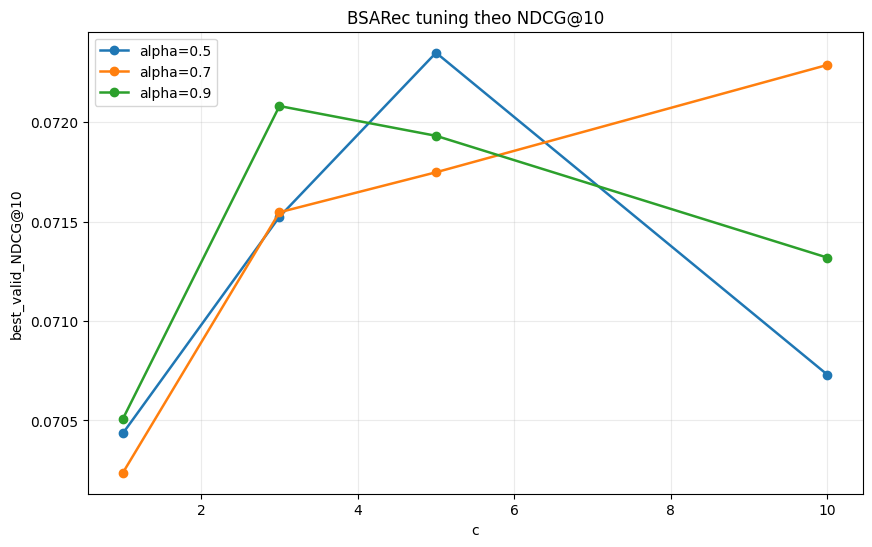

Saved: /kaggle/working/seqrec_outputs/bsarec_tuning_heatmap.png


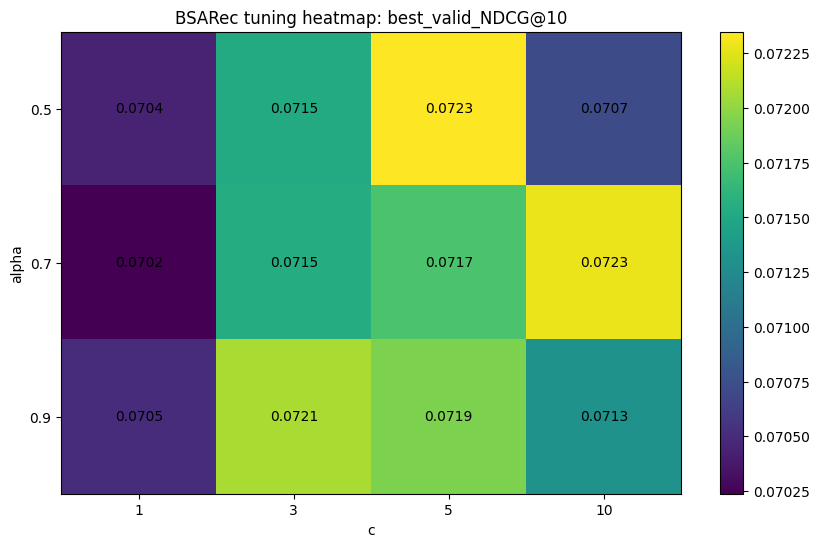

In [36]:
def plot_bsarec_tuning_results(tuning_df: pd.DataFrame):
    """Vẽ biểu đồ kết quả tuning BSARec."""

    if tuning_df is None or tuning_df.empty:
        print("Không có dữ liệu tuning để vẽ.")
        return

    metric_col = f"best_valid_{cfg.tuning_metric}"

    # Biểu đồ đường: so sánh metric theo c cho từng alpha.
    fig, ax = plt.subplots(figsize=(10, 6))

    for alpha in sorted(tuning_df["alpha"].unique()):
        sub = tuning_df[tuning_df["alpha"] == alpha].sort_values("c")
        ax.plot(
            sub["c"],
            sub[metric_col],
            marker="o",
            linewidth=1.8,
            label=f"alpha={alpha}",
        )

    ax.set_title(f"BSARec tuning theo {cfg.tuning_metric}")
    ax.set_xlabel("c")
    ax.set_ylabel(metric_col)
    ax.grid(alpha=0.25)
    ax.legend()

    line_path = os.path.join(cfg.output_dir, "bsarec_tuning_line_chart.png")
    fig.savefig(line_path, dpi=160, bbox_inches="tight")
    print("Saved:", line_path)
    plt.show()

    # Biểu đồ heatmap đơn giản bằng matplotlib.
    pivot = tuning_df.pivot_table(index="alpha", columns="c", values=metric_col, aggfunc="max")
    fig, ax = plt.subplots(figsize=(10, 6))

    im = ax.imshow(pivot.values, aspect="auto")

    ax.set_title(f"BSARec tuning heatmap: {metric_col}")
    ax.set_xlabel("c")
    ax.set_ylabel("alpha")

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)

    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            value = pivot.values[i, j]
            if not np.isnan(value):
                ax.text(j, i, f"{value:.4f}", ha="center", va="center")

    fig.colorbar(im, ax=ax)
    heatmap_path = os.path.join(cfg.output_dir, "bsarec_tuning_heatmap.png")
    fig.savefig(heatmap_path, dpi=160, bbox_inches="tight")
    print("Saved:", heatmap_path)
    plt.show()


plot_bsarec_tuning_results(bsarec_tuning_df)


## 17. Chạy benchmark cuối cùng với cấu hình BSARec tốt nhất


In [37]:
all_results = []
all_history = []

for model_name in cfg.models_to_run:
    if model_name.lower() == "popularity":
        all_results.append(evaluate_popularity())
    else:
        if model_name.lower() == "bsarec":
            # Lúc này cfg.bsarec_alpha và cfg.bsarec_c đã được cập nhật từ tuning.
            model_args = make_model_args(
                num_items=num_items,
                bsarec_alpha=cfg.bsarec_alpha,
                bsarec_c=cfg.bsarec_c,
            )
            run_name = f"BSARec_best_alpha_{cfg.bsarec_alpha}_c_{cfg.bsarec_c}"
            run_name = sanitize_run_name(run_name)
        else:
            model_args = make_model_args(num_items=num_items)
            run_name = model_name

        result, history = train_neural_model(
            model_name=model_name,
            model_args=model_args,
            run_name=run_name,
            max_epochs=cfg.epochs,
            patience=cfg.patience,
            selection_metric=cfg.tuning_metric,
            evaluate_test=True,
            save_artifacts=True,
        )

        all_results.append(result)
        all_history.extend(history)

results_df = pd.DataFrame(all_results)
history_df = pd.DataFrame(all_history)

metric_cols = ["HR@5", "HR@10", "HR@20", "NDCG@5", "NDCG@10", "NDCG@20", "MRR"]

results_df = results_df.sort_values(
    ["NDCG@10", "HR@10", "MRR"],
    ascending=False,
).reset_index(drop=True)

results_df.insert(0, "rank", np.arange(1, len(results_df) + 1))

results_path = os.path.join(cfg.output_dir, "beauty_5models_full_ranking_results.csv")
history_path = os.path.join(cfg.output_dir, "beauty_5models_training_history.csv")

results_df.to_csv(results_path, index=False)
history_df.to_csv(history_path, index=False)

best_row = results_df.iloc[0].to_dict()
best_package_src = best_row.get("package_path")

best_package_path = os.path.join(cfg.output_dir, "best_model_package.pt")
best_info_path = os.path.join(cfg.output_dir, "best_model_info.json")

if isinstance(best_package_src, str) and os.path.exists(best_package_src):
    shutil.copyfile(best_package_src, best_package_path)
    best_row["best_model_package_path"] = best_package_path

with open(best_info_path, "w", encoding="utf-8") as f:
    json.dump(json_ready(best_row), f, ensure_ascii=False, indent=2)

print("Saved:", results_path)
print("Saved:", history_path)
print("Saved:", best_package_path)
print("Saved:", best_info_path)

display(results_df)


TEST Popularity: HR@5: 0.0081 | NDCG@5: 0.0044 | HR@10: 0.0120 | NDCG@10: 0.0056 | HR@20: 0.0204 | NDCG@20: 0.0076 | MRR: 0.0057
Saved package: /kaggle/working/seqrec_outputs/Popularity_best_package.pt

===== GRU4Rec =====
Parameters: 831,040
GRU4Rec epoch 001 | train loss 0.5587 | valid loss 9.1481 | valid NDCG@10 0.0079 | valid MRR 0.0075
GRU4Rec epoch 002 | train loss 0.5048 | valid loss 9.0757 | valid NDCG@10 0.0076 | valid MRR 0.0079
GRU4Rec epoch 003 | train loss 0.4731 | valid loss 8.9606 | valid NDCG@10 0.0068 | valid MRR 0.0077
GRU4Rec epoch 004 | train loss 0.4401 | valid loss 8.9170 | valid NDCG@10 0.0072 | valid MRR 0.0083
GRU4Rec epoch 005 | train loss 0.4260 | valid loss 8.8819 | valid NDCG@10 0.0078 | valid MRR 0.0088
GRU4Rec epoch 006 | train loss 0.4077 | valid loss 8.9006 | valid NDCG@10 0.0092 | valid MRR 0.0105
GRU4Rec epoch 007 | train loss 0.3960 | valid loss 8.8429 | valid NDCG@10 0.0095 | valid MRR 0.0095
GRU4Rec epoch 008 | train loss 0.3850 | valid loss 8.8618

,rank,model,run_name,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20,MRR,...,train_seconds,parameters,checkpoint_path,package_path,best_valid_HR@5,best_valid_NDCG@5,best_valid_HR@20,best_valid_NDCG@20,alpha,c
0,1,BSARec,BSARec_best_alpha_0p5_c_5,0.067433,0.048735,0.095023,0.057593,0.130305,0.066463,0.052558,...,641.563420,878208,/kaggle/working/seqrec_outputs/BSARec_best_alp...,/kaggle/working/seqrec_outputs/BSARec_best_alp...,0.086661,0.062295,0.160712,0.083224,0.5,5.0
1,2,BERT4Rec,BERT4Rec,0.050038,0.034433,0.075661,0.042717,0.112373,0.051961,0.039234,...,803.473651,877888,/kaggle/working/seqrec_outputs/BERT4Rec_best.pt,/kaggle/working/seqrec_outputs/BERT4Rec_best_p...,0.070474,0.048624,0.142199,0.068728,NaN,NaN
2,3,SASRec,SASRec,0.030989,0.020516,0.048607,0.026163,0.074453,0.032657,0.024674,...,388.437137,877824,/kaggle/working/seqrec_outputs/SASRec_best.pt,/kaggle/working/seqrec_outputs/SASRec_best_pac...,0.041095,0.026822,0.097393,0.042697,NaN,NaN
3,4,GRU4Rec,GRU4Rec,0.018334,0.011282,0.030855,0.015286,0.049591,0.019979,0.014985,...,404.636811,831040,/kaggle/working/seqrec_outputs/GRU4Rec_best.pt,/kaggle/working/seqrec_outputs/GRU4Rec_best_pa...,0.023789,0.014452,0.064526,0.025902,NaN,NaN
4,5,Popularity,Popularity,0.008094,0.004394,0.011984,0.005613,0.020436,0.007650,0.005655,...,0.000000,0,,/kaggle/working/seqrec_outputs/Popularity_best...,NaN,NaN,NaN,NaN,NaN,NaN


## 17.1. Kiểm tra đã chạy đủ 5 model và Popularity có MRR

In [38]:
# Cell này giúp kiểm tra nhanh đúng yêu cầu:
# - Có đủ 5 model.
# - Popularity có cột MRR sau đánh giá full-ranking.

expected_models = {"Popularity", "GRU4Rec", "SASRec", "BERT4Rec", "BSARec"}
actual_models = set(results_df["model"].tolist())

print("Expected models:", sorted(expected_models))
print("Actual models  :", sorted(actual_models))

missing_models = expected_models - actual_models
extra_models = actual_models - expected_models

if missing_models:
    print("Thiếu model:", missing_models)
if extra_models:
    print("Model ngoài dự kiến:", extra_models)

assert missing_models == set(), "Chưa chạy đủ 5 model."
assert "MRR" in results_df.columns, "Bảng kết quả chưa có cột MRR."
assert not results_df.loc[results_df["model"] == "Popularity", "MRR"].isna().any(), "Popularity chưa có MRR."

display(results_df[results_df["model"] == "Popularity"][["model", "HR@5", "NDCG@5", "HR@10", "NDCG@10", "HR@20", "NDCG@20", "MRR"]])


Expected models: ['BERT4Rec', 'BSARec', 'GRU4Rec', 'Popularity', 'SASRec']
Actual models  : ['BERT4Rec', 'BSARec', 'GRU4Rec', 'Popularity', 'SASRec']


,model,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20,MRR
4,Popularity,0.008094,0.004394,0.011984,0.005613,0.020436,0.00765,0.005655


## 18. Bảng kết quả cuối cùng


In [39]:
format_dict = {col: "{:.4f}" for col in metric_cols}
format_dict.update({
    "train_seconds": "{:.1f}",
    "best_valid_score": "{:.4f}",
    "best_valid_MRR": "{:.4f}",
    "best_valid_NDCG@10": "{:.4f}",
    "parameters": "{:,}",
})

styled = (
    results_df.style
    .format(format_dict, na_rep="-")
    .background_gradient(subset=["NDCG@10", "MRR"], cmap="Greens")
)

display(styled)


,rank,model,run_name,HR@5,NDCG@5,HR@10,NDCG@10,HR@20,NDCG@20,MRR,best_epoch,best_valid_MRR,best_valid_NDCG@10,best_valid_HR@10,selection_metric,best_valid_score,train_seconds,parameters,checkpoint_path,package_path,best_valid_HR@5,best_valid_NDCG@5,best_valid_HR@20,best_valid_NDCG@20,alpha,c
0,1,BSARec,BSARec_best_alpha_0p5_c_5,0.0674,0.0487,0.0950,0.0576,0.1303,0.0665,0.0526,34.000000,0.0656,0.0727,0.119170,NDCG@10,0.0727,641.6,"878,208",/kaggle/working/seqrec_outputs/BSARec_best_alpha_0p5_c_5_best.pt,/kaggle/working/seqrec_outputs/BSARec_best_alpha_0p5_c_5_best_package.pt,0.086661,0.062295,0.160712,0.083224,0.500000,5.000000
1,2,BERT4Rec,BERT4Rec,0.0500,0.0344,0.0757,0.0427,0.1124,0.0520,0.0392,60.000000,0.0525,0.0581,0.099808,NDCG@10,0.0581,803.5,"877,888",/kaggle/working/seqrec_outputs/BERT4Rec_best.pt,/kaggle/working/seqrec_outputs/BERT4Rec_best_package.pt,0.070474,0.048624,0.142199,0.068728,-,-
2,3,SASRec,SASRec,0.0310,0.0205,0.0486,0.0262,0.0745,0.0327,0.0247,25.000000,0.0315,0.0347,0.065778,NDCG@10,0.0347,388.4,"877,824",/kaggle/working/seqrec_outputs/SASRec_best.pt,/kaggle/working/seqrec_outputs/SASRec_best_package.pt,0.041095,0.026822,0.097393,0.042697,-,-
3,4,GRU4Rec,GRU4Rec,0.0183,0.0113,0.0309,0.0153,0.0496,0.0200,0.0150,57.000000,0.0189,0.0201,0.041408,NDCG@10,0.0201,404.6,"831,040",/kaggle/working/seqrec_outputs/GRU4Rec_best.pt,/kaggle/working/seqrec_outputs/GRU4Rec_best_package.pt,0.023789,0.014452,0.064526,0.025902,-,-
4,5,Popularity,Popularity,0.0081,0.0044,0.0120,0.0056,0.0204,0.0076,0.0057,-,-,-,-,,-,0.0,0,,/kaggle/working/seqrec_outputs/Popularity_best_package.pt,-,-,-,-,-,-


## 19. Biểu đồ quá trình huấn luyện


Saved: /kaggle/working/seqrec_outputs/training_curves_by_model.png


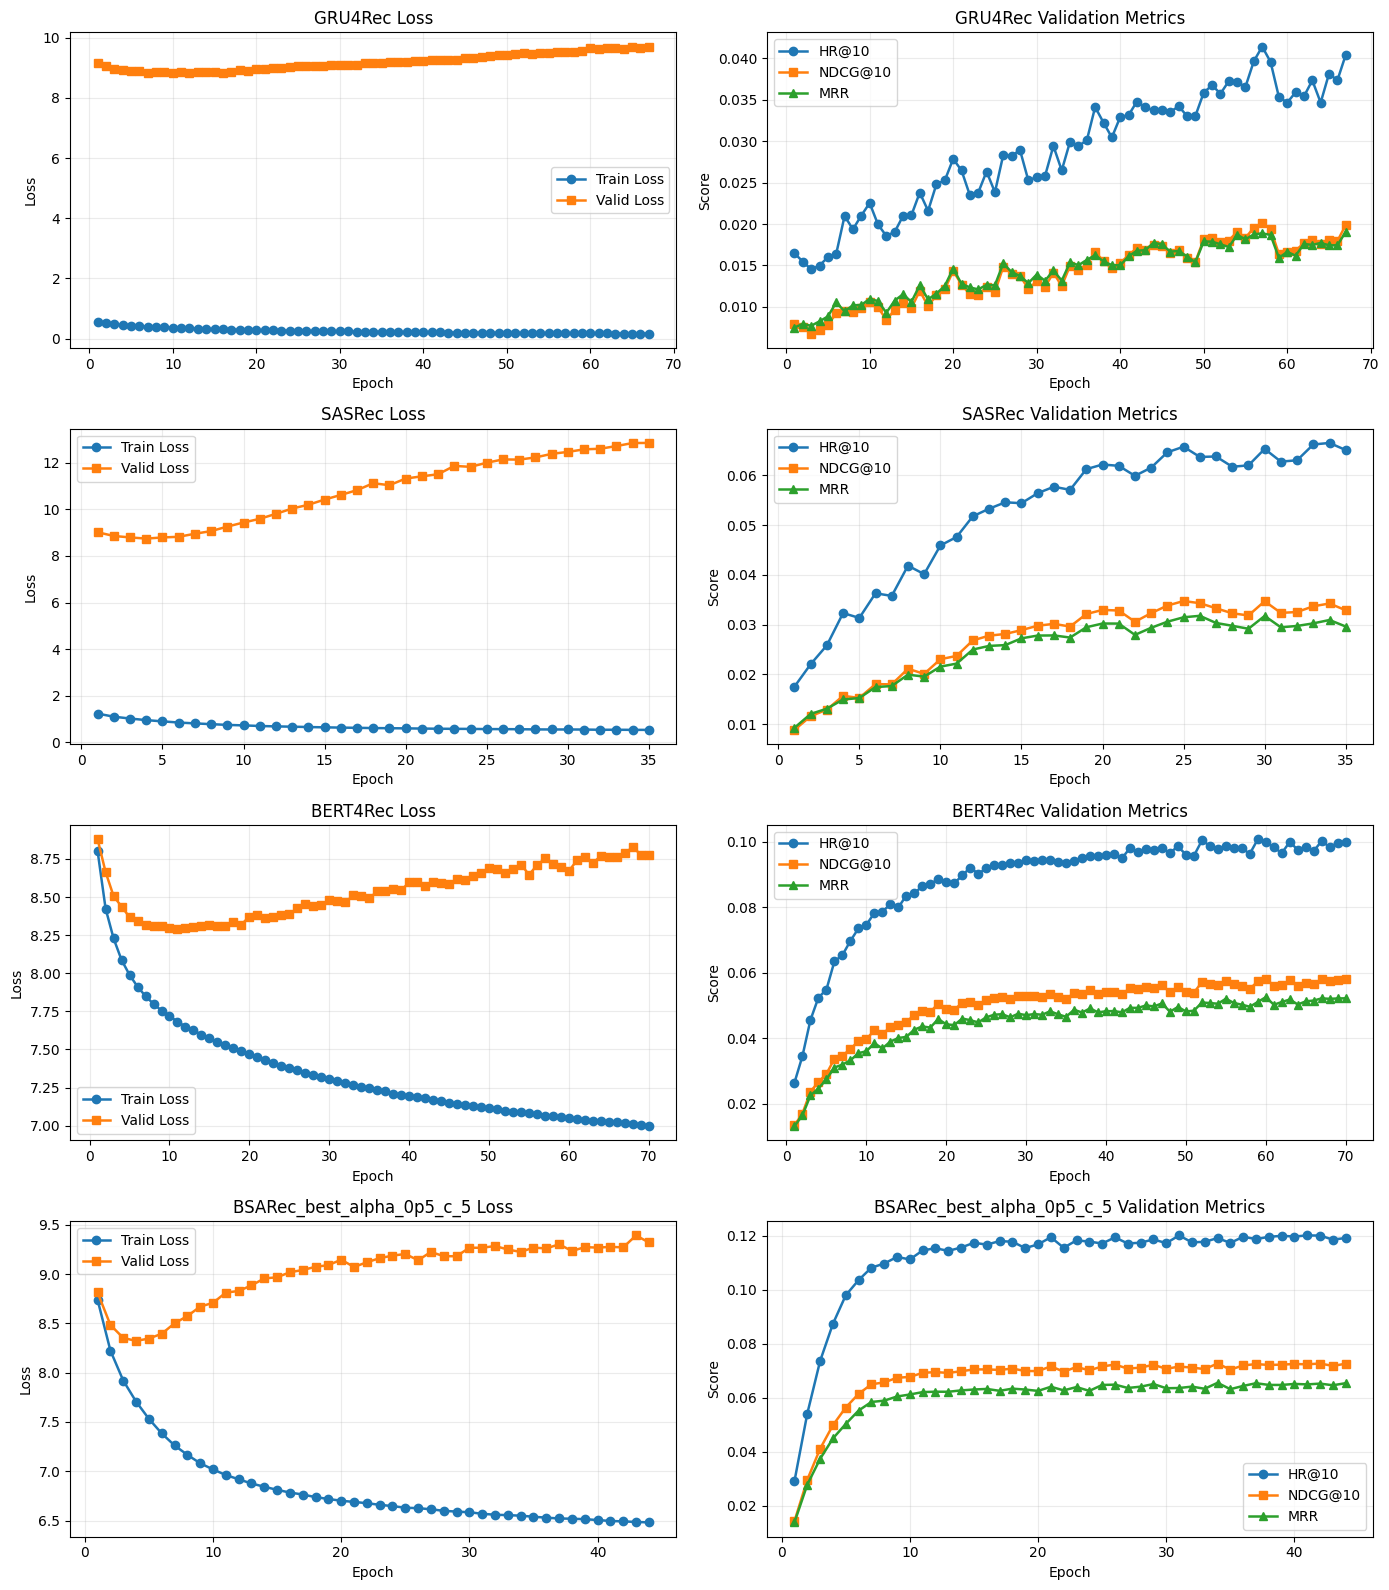

In [40]:
if len(history_df) > 0:
    plot_models = list(history_df["run_name"].drop_duplicates())

    fig, axes = plt.subplots(
        len(plot_models),
        2,
        figsize=(14, 4 * len(plot_models)),
        squeeze=False,
    )

    for row_idx, run_name in enumerate(plot_models):
        h = history_df[history_df["run_name"] == run_name].sort_values("epoch")

        ax_loss = axes[row_idx, 0]
        ax_metric = axes[row_idx, 1]

        ax_loss.plot(h["epoch"], h["train_loss"], marker="o", label="Train Loss", linewidth=1.8)
        ax_loss.plot(h["epoch"], h["valid_loss"], marker="s", label="Valid Loss", linewidth=1.8)

        ax_loss.set_title(f"{run_name} Loss")
        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Loss")
        ax_loss.grid(alpha=0.25)
        ax_loss.legend()

        ax_metric.plot(h["epoch"], h["valid_HR@10"], marker="o", label="HR@10", linewidth=1.8)
        ax_metric.plot(h["epoch"], h["valid_NDCG@10"], marker="s", label="NDCG@10", linewidth=1.8)
        ax_metric.plot(h["epoch"], h["valid_MRR"], marker="^", label="MRR", linewidth=1.8)

        ax_metric.set_title(f"{run_name} Validation Metrics")
        ax_metric.set_xlabel("Epoch")
        ax_metric.set_ylabel("Score")
        ax_metric.grid(alpha=0.25)
        ax_metric.legend()

    fig.tight_layout()

    train_plot_path = os.path.join(cfg.output_dir, "training_curves_by_model.png")
    fig.savefig(train_plot_path, dpi=160, bbox_inches="tight")

    print("Saved:", train_plot_path)
    plt.show()

else:
    print("Không có history model neural để vẽ.")


## 20. Biểu đồ so sánh các mô hình


Saved: /kaggle/working/seqrec_outputs/model_metrics_comparison.png


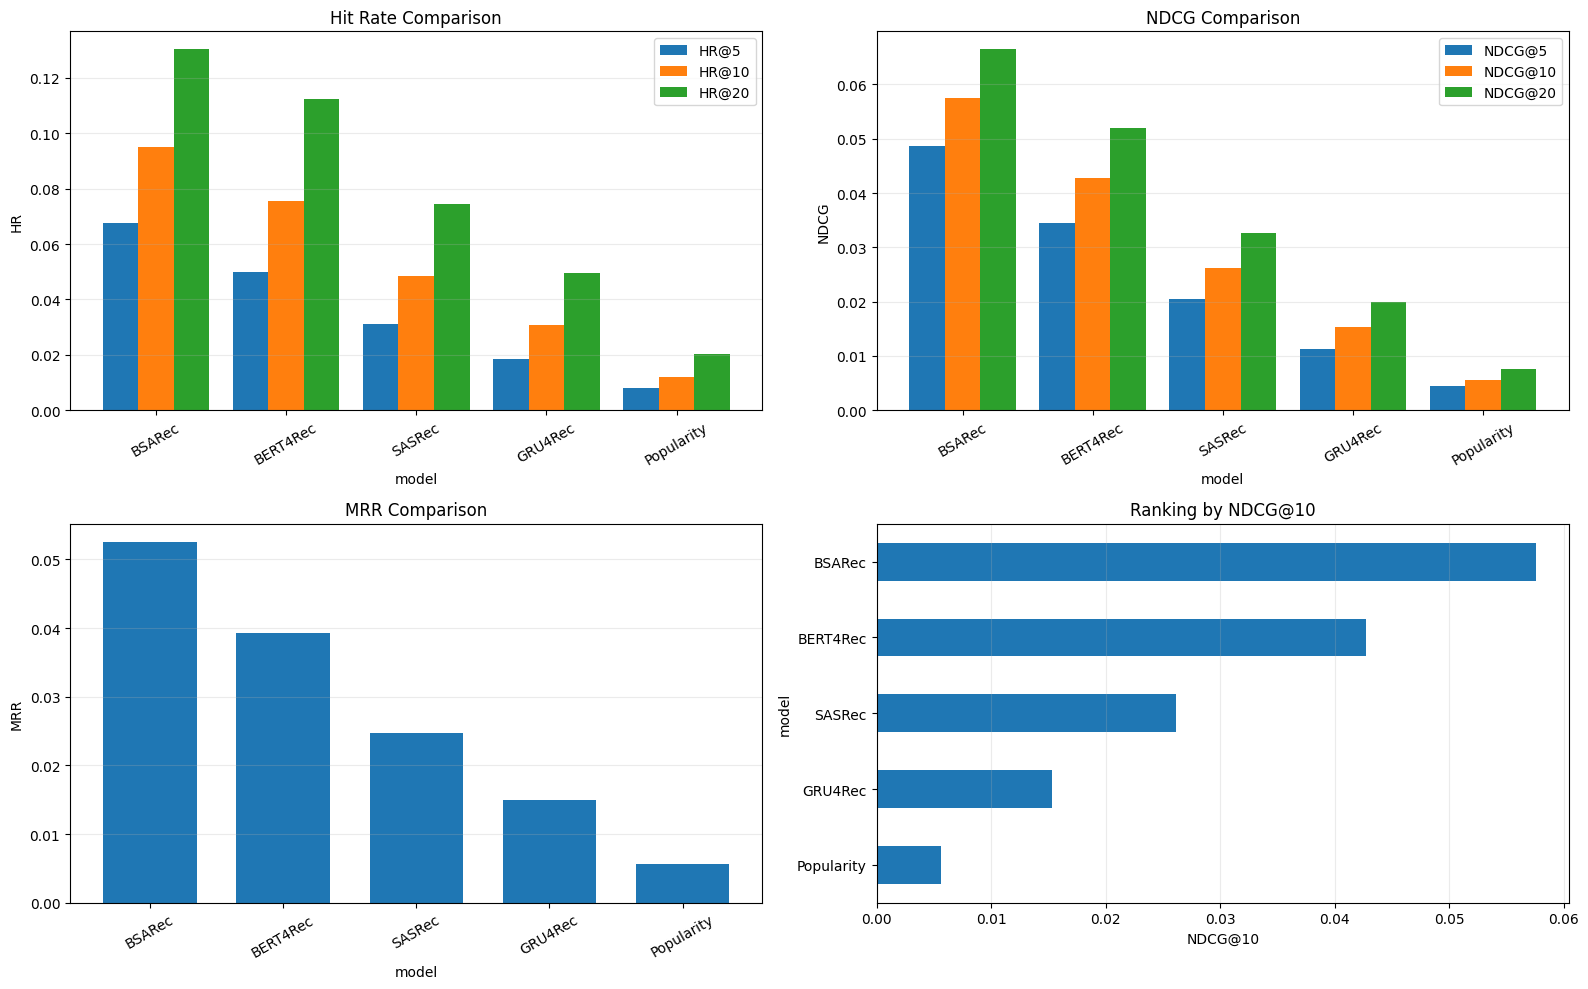

In [41]:
comparison_metrics = ["HR@5", "HR@10", "HR@20", "NDCG@5", "NDCG@10", "NDCG@20", "MRR"]
plot_df = results_df.set_index("model")[comparison_metrics]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

plot_df[["HR@5", "HR@10", "HR@20"]].plot(kind="bar", ax=axes[0], width=0.82)
axes[0].set_title("Hit Rate Comparison")
axes[0].set_ylabel("HR")
axes[0].grid(axis="y", alpha=0.25)
axes[0].tick_params(axis="x", rotation=30)

plot_df[["NDCG@5", "NDCG@10", "NDCG@20"]].plot(kind="bar", ax=axes[1], width=0.82)
axes[1].set_title("NDCG Comparison")
axes[1].set_ylabel("NDCG")
axes[1].grid(axis="y", alpha=0.25)
axes[1].tick_params(axis="x", rotation=30)

plot_df[["MRR"]].plot(kind="bar", ax=axes[2], legend=False, width=0.7)
axes[2].set_title("MRR Comparison")
axes[2].set_ylabel("MRR")
axes[2].grid(axis="y", alpha=0.25)
axes[2].tick_params(axis="x", rotation=30)

rank_metric = results_df.sort_values("rank").set_index("model")["NDCG@10"]
rank_metric.plot(kind="barh", ax=axes[3])

axes[3].set_title("Ranking by NDCG@10")
axes[3].set_xlabel("NDCG@10")
axes[3].grid(axis="x", alpha=0.25)
axes[3].invert_yaxis()

fig.tight_layout()

comparison_plot_path = os.path.join(cfg.output_dir, "model_metrics_comparison.png")
fig.savefig(comparison_plot_path, dpi=160, bbox_inches="tight")

print("Saved:", comparison_plot_path)
plt.show()


## 21. Ghi chú khi báo cáo kết quả tuning

Khi trình bày với giảng viên, có thể nói:

> Đối với BSARec, em không chọn trực tiếp `alpha` và `c` bằng tập test. Em thử nhiều cấu hình trên tập validation, sau đó chọn cấu hình có `NDCG@10` validation tốt nhất. Cấu hình tốt nhất này mới được dùng để huấn luyện/đánh giá cuối cùng trên tập test. Cách này giúp tránh rò rỉ dữ liệu test và làm kết quả khách quan hơn.

Nếu thời gian Kaggle hạn chế, có thể giảm grid:

```python
cfg.bsarec_alpha_grid = (0.7, 0.9)
cfg.bsarec_c_grid = (1, 3, 5)
cfg.tuning_epochs = 30
cfg.tuning_patience = 3
```
